In [1]:
import pennylane as qp
qml = qp
from pennylane import numpy as np

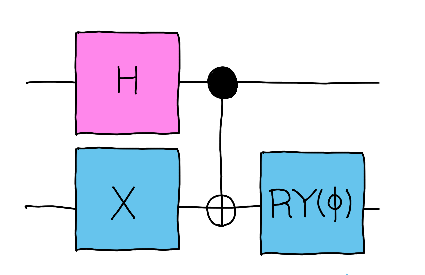

In [2]:
def circuit(theta): # Write any arguments you need here
    """
    This quantum function implements the circuit shown above
    and returns the output quantum state
    """

    ####################
    ###YOUR CODE HERE###
    ####################
    qp.Hadamard(wires=0)
    qp.PauliX(wires=1)
    qp.CNOT(wires=[0,1])
    qp.RY(theta, wires=1)

    return qp.state()

In [3]:
dev_qubit = qp.device('default.qubit', wires = ['alice', 'bob']) # Define the device here
dev_mixed = qp.device('default.mixed', wires = ['alice', 'bob']) # Define the device here

@qp.qnode(dev_qubit) # Choose the device you want
def example_circuit(theta):
    
    qp.RX(theta, wires = 'alice') # Complete with wires in the device
    qp.CNOT(wires = ['alice', 'bob']) # Complete with wires in the device
    
    return qp.state()

print(example_circuit(0.3))

[0.98877108+0.j         0.        +0.j         0.        +0.j
 0.        -0.14943813j]


In [4]:
dev = qp.device('default.qubit', wires = 2) # Define the device

circuit_qnode = qp.QNode(circuit, dev) # Assign a QNode to circuit"

print(circuit_qnode(0.3))

[-0.10566872+0.j  0.69916673+0.j  0.69916673+0.j  0.10566872+0.j]


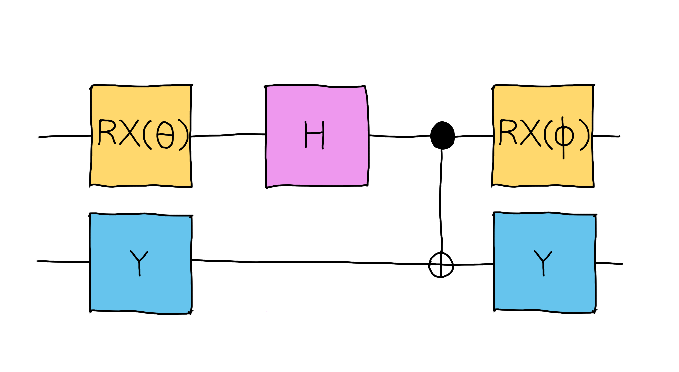

In [5]:
def subcircuit_1(angle):

    ####################
    ###YOUR CODE HERE###
    ####################
    qp.RX(angle, wires = 0)
    qp.PauliY(wires = 1)

    # No need to return anything

def subcircuit_2():

    ####################
    ###YOUR CODE HERE###
    ####################
    qp.Hadamard(wires = 0)
    qp.CNOT(wires = [0,1])

    # No need to return anything

dev = qp.device('default.qubit', wires = 2)

# Decorate this function to create a QNode
@qp.qnode(dev)
def full_circuit(theta, phi):

    ####################
    ###YOUR CODE HERE###
    ####################
    subcircuit_1(theta)
    subcircuit_2()
    subcircuit_1(phi)

    # Return the quantum state
    return qp.state()

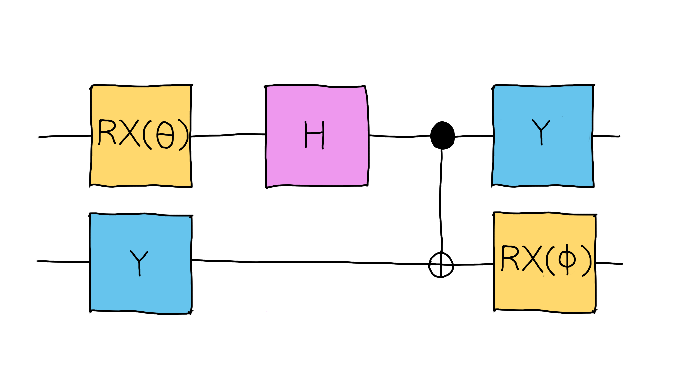

In [6]:
def subcircuit_1(angle, wire_list):
    """
    Implements the first subcircuit as a function of the RX gate angle
    and the list of wires wire_list on which the gates are applied
    """
    ####################
    ###YOUR CODE HERE###
    ####################
    qp.RX(angle, wires = wire_list[0])
    qp.PauliY(wires = wire_list[1])

def subcircuit_2(wire_list):
    """
    Implements the second subcircuit as a function of the list of wires 
    wire_list on which the gates are applied
    """

    ####################
    ###YOUR CODE HERE###
    ####################
    qp.Hadamard(wires = wire_list[0])
    qp.CNOT(wires = [wire_list[0],wire_list[1]])

dev = qp.device("default.qubit", wires = [0,1])

@qp.qnode(dev)
def full_circuit(theta, phi):
    """
    Builds the full quantum circuit given the input parameters
    """

    ####################
    ###YOUR CODE HERE###
    ####################
    subcircuit_1(theta, [0, 1])
    subcircuit_2([0, 1])
    subcircuit_1(phi, [1, 0])

    return qp.state()